**Import dependencies**

In [1]:
from fastai.vision.all import *

In [2]:
import inspect
import pandas as pd
pd.set_option('max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def inspect_default_args(target, annotations: bool=False):
    # Get the argument names
    args = inspect.getfullargspec(target).args
    # Get the default values
    defaults = inspect.getfullargspec(target).defaults

    index = ["Default Value"]

    # Pad defaults
    defaults = [None]*(len(args)-len(defaults)) + list(defaults)
    if annotations:
        index.append("Annotation")
        annotations = inspect.getfullargspec(target).annotations.values()
        # Pad annotations
        annotations = [None]*(len(args)-len(annotations)) + list(annotations)
        default_args = {arg:[df, annot] for arg,df,annot in zip(args, defaults, annotations)}
    else:
        default_args = {arg:[default] for arg,default in zip(args, defaults)}
        
    return pd.DataFrame(default_args, index=index).T

**Define path to dataset**

In [3]:
path = untar_data(URLs.PASCAL_2007)

In [4]:
path.ls()

(#9) [Path('/home/innom-dt/.fastai/data/pascal_2007/segmentation'),Path('/home/innom-dt/.fastai/data/pascal_2007/test'),Path('/home/innom-dt/.fastai/data/pascal_2007/valid.json'),Path('/home/innom-dt/.fastai/data/pascal_2007/models'),Path('/home/innom-dt/.fastai/data/pascal_2007/train'),Path('/home/innom-dt/.fastai/data/pascal_2007/test.csv'),Path('/home/innom-dt/.fastai/data/pascal_2007/train.json'),Path('/home/innom-dt/.fastai/data/pascal_2007/train.csv'),Path('/home/innom-dt/.fastai/data/pascal_2007/test.json')]

**Get Lables**

In [5]:
!head $path/'train.csv'

fname,labels,is_valid
000005.jpg,chair,True
000007.jpg,car,True
000009.jpg,horse person,True
000012.jpg,car,False
000016.jpg,bicycle,True
000017.jpg,person horse,False
000019.jpg,cat,True
000020.jpg,car,True
000021.jpg,dog person,True


In [6]:
!tail -n +2 $path/'train.csv' | wc -l

5011


In [7]:
df = pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


**Define Splitter**

In [8]:
splitter = ColSplitter('is_valid')

**Define Getters**

In [9]:
inspect_default_args(ColReader)

,Default Value
self,None
cols,None
pref,
suff,
label_delim,None


In [10]:
get_x = ColReader('fname', pref=str(path/'train') + os.path.sep)
get_y = ColReader('labels', label_delim=' ')

**Define Transforms**

In [11]:
item_tfms = [Resize(460)]
batch_tfms = aug_transforms(size=224)

**Define custom DataBlock**

In [12]:
pascal = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   splitter=splitter,
                   get_x=get_x,
                   get_y=get_y,
                   item_tfms=item_tfms,
                   batch_tfms=batch_tfms
                  )

**Define batch size**

In [13]:
bs = 128

**Define DataLoaders object**

In [14]:
dls = pascal.dataloaders(df, bs=bs)

**Verify DataLoaders object**

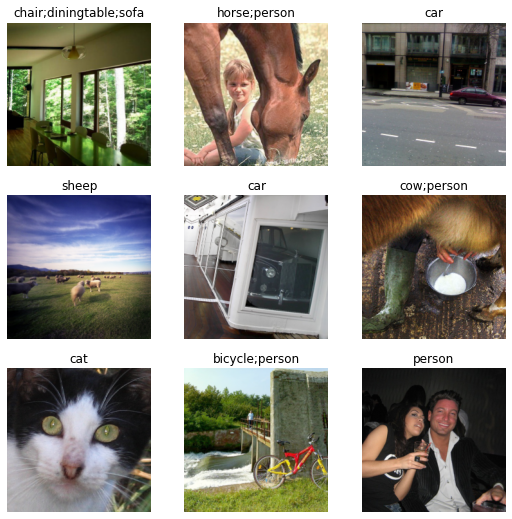

In [15]:
dls.show_batch()

**Inspect Learner parameters**

In [16]:
inspect_default_args(vision_learner)

,Default Value
dls,None
arch,None
normalize,True
n_out,None
pretrained,True
loss_func,None
opt_func,<function Adam at 0x7f7573ea23b0>
lr,0.001
splitter,None
cbs,None


**Define model**

In [17]:
model = resnet18

**Define [metrics](https://docs.fast.ai/metrics.html)**

In [18]:
f1_macro = F1ScoreMulti(thresh=0.5, average='macro')
f1_macro.name = 'F1(macro)'
f1_samples = F1ScoreMulti(thresh=0.5, average='samples')
f1_samples.name = 'F1(samples)'
metrics = [partial(accuracy_multi, thresh=0.5), f1_macro, f1_samples]

**Define Learner object**

In [19]:
learn = vision_learner(dls, model, metrics=metrics).to_fp16()

**Find learning rate**

In [20]:
inspect_default_args(learn.lr_find)

,Default Value
self,None
start_lr,0.0
end_lr,10
num_it,100
stop_div,True
show_plot,True
suggest_funcs,<function valley at 0x7f7573c2d510>


**Define [suggestion methods](https://docs.fast.ai/callback.schedule.html#Suggestion-Methods)**

In [21]:
suggest_funcs = [valley, minimum, steep]

SuggestedLRs(valley=0.001737800776027143, minimum=0.03630780577659607, steep=0.033113110810518265)

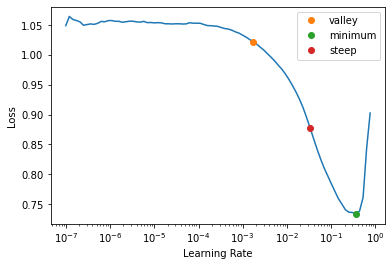

In [22]:
learn.lr_find(suggest_funcs=suggest_funcs)

**Define learning rate**

In [23]:
lr = 2e-2
lr

0.02

**Define number of epochs**

In [24]:
epochs = 2

**Fine tune model**

In [25]:
inspect_default_args(learn.fine_tune)

,Default Value
self,None
epochs,None
base_lr,0.002
freeze_epochs,1
lr_mult,100
pct_start,0.3
div,5.0
lr_max,None
div_final,100000.0
wd,None


In [26]:
learn.fine_tune(epochs, base_lr=lr)

epoch,train_loss,valid_loss,accuracy_multi,F1(macro),F1(samples),time
0,0.719403,0.187116,0.941335,0.589620,0.682678,00:08


epoch,train_loss,valid_loss,accuracy_multi,F1(macro),F1(samples),time
0,0.154630,0.157813,0.949004,0.616463,0.650203,00:08
1,0.127957,0.106259,0.962829,0.684221,0.724042,00:08


**Select a test image**

In [27]:
import PIL

In [28]:
files = get_image_files(path/'train')
files[0]

Path('/home/innom-dt/.fastai/data/pascal_2007/train/002034.jpg')

In [29]:
test_file = files[1]
test_file.name

'004259.jpg'

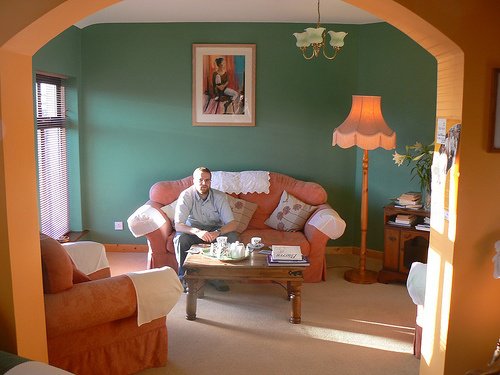

In [30]:
test_img = PIL.Image.open(test_file)
test_img

**Make a prediction on a single image using a file path**

In [31]:
learn.predict(test_file)

((#4) ['chair','diningtable','person','sofa'],
 TensorBase([False, False, False, False, False, False, False, False,  True, False,
          True, False, False, False,  True, False, False,  True, False, False]),
 TensorBase([3.6358e-03, 6.1663e-04, 4.0860e-03, 7.9783e-04, 1.1961e-02, 1.0242e-03,
         3.3374e-03, 1.4672e-02, 9.0431e-01, 1.3045e-03, 5.4801e-01, 4.7691e-02,
         7.8462e-03, 5.0927e-04, 6.8878e-01, 2.8368e-01, 4.5831e-04, 7.8366e-01,
         9.1819e-04, 1.6593e-02]))

**Make a prediction on a single image using a [fastai.vision.core.PILImage](https://docs.fast.ai/vision.core.html#PILImage)**

In [32]:
learn.predict(PILImage(test_img))

((#4) ['chair','diningtable','person','sofa'],
 TensorBase([False, False, False, False, False, False, False, False,  True, False,
          True, False, False, False,  True, False, False,  True, False, False]),
 TensorBase([3.6358e-03, 6.1663e-04, 4.0860e-03, 7.9783e-04, 1.1961e-02, 1.0242e-03,
         3.3374e-03, 1.4672e-02, 9.0431e-01, 1.3045e-03, 5.4801e-01, 4.7691e-02,
         7.8462e-03, 5.0927e-04, 6.8878e-01, 2.8368e-01, 4.5831e-04, 7.8366e-01,
         9.1819e-04, 1.6593e-02]))

**Make a prediction on a single image using a [fastai.torch_core.tensor](https://docs.fast.ai/torch_core.html#tensor)**

In [33]:
learn.predict(tensor(test_img))

((#4) ['chair','diningtable','person','sofa'],
 TensorBase([False, False, False, False, False, False, False, False,  True, False,
          True, False, False, False,  True, False, False,  True, False, False]),
 TensorBase([3.6358e-03, 6.1663e-04, 4.0860e-03, 7.9783e-04, 1.1961e-02, 1.0242e-03,
         3.3374e-03, 1.4672e-02, 9.0431e-01, 1.3045e-03, 5.4801e-01, 4.7691e-02,
         7.8462e-03, 5.0927e-04, 6.8878e-01, 2.8368e-01, 4.5831e-04, 7.8366e-01,
         9.1819e-04, 1.6593e-02]))

In [34]:
learn.dls.vocab

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

In [35]:
[category for detected, category in zip(learn.predict(test_file)[1], learn.dls.vocab) if detected]

['chair', 'diningtable', 'person', 'sofa']

**Make predictions for a group of images**

In [36]:
inspect_default_args(learn.show_results)

,Default Value
self,None
ds_idx,1
dl,None
max_n,9
shuffle,True


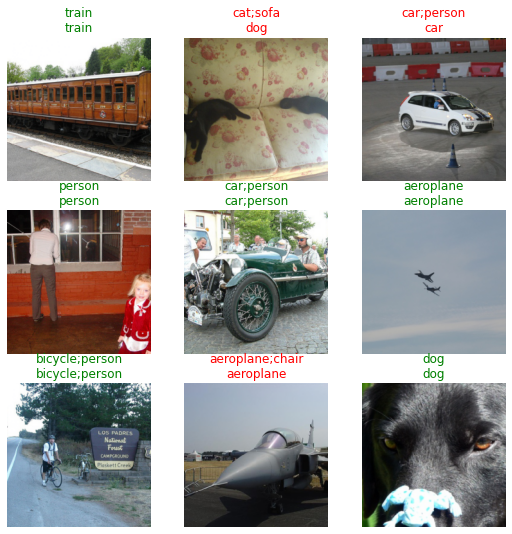

In [37]:
learn.show_results()

**Define an Interpretation object**

In [38]:
inspect_default_args(Interpretation.from_learner)

,Default Value
cls,None
learn,None
ds_idx,1
dl,None
act,None


In [39]:
interp = Interpretation.from_learner(learn)

**Plot top losses**

In [40]:
inspect_default_args(interp.plot_top_losses)

,Default Value
self,None
k,None
largest,True


/home/innom-dt/mambaforge/envs/fastai-base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1580: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/home/innom-dt/mambaforge/envs/fastai-base/lib/python3.10/site-packages/fastai/torch_core.py:476: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  ax = ax.append(pd.Series({label: o}))
/home/innom-dt/mambaforge/envs/fastai-base/lib/python3.10/site-packages/fastai/torch_core.py:476: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  ax = ax.append(pd.Series({label: o}))
/home/innom-dt/mambaforge/envs/fastai-base/lib/python3.10/site-packages/fastai/torch_core.py:476: Fut

,target,predicted,probabilities,loss
0,dog;motorbike,cow,"TensorBase([2.1568e-06, 9.4613e-05, 1.5567e-05, 2.9541e-05, 2.4729e-04, 2.0785e-05,\n 1.6293e-03, 8.2035e-06, 5.2748e-04, 8.7621e-01, 1.3238e-04, 1.3443e-01,\n 1.2075e-01, 4.5045e-05, 1.5131e-02, 1.7131e-04, 1.8689e-02, 3.3274e-04,\n 3.8831e-05, 1.2805e-05])",0.7134957313537598
1,chair;diningtable;person,person;train,"TensorBase([4.0695e-05, 7.8767e-03, 3.3666e-04, 8.5257e-04, 1.3670e-03, 3.3844e-02,\n 1.1636e-01, 2.0988e-04, 7.6362e-03, 2.4534e-03, 2.7587e-04, 1.5367e-03,\n 5.6639e-03, 1.3250e-03, 7.6083e-01, 9.1610e-03, 2.3969e-04, 3.5519e-03,\n 5.0672e-01, 5.6809e-04])",0.7122065424919128
2,horse;person,pottedplant,"TensorBase([5.7703e-04, 5.1197e-03, 1.8440e-02, 2.4823e-03, 5.9111e-03, 1.6485e-03,\n 1.1642e-02, 1.3406e-03, 1.4729e-02, 1.6744e-03, 2.4344e-03, 3.5936e-03,\n 6.4620e-04, 1.5306e-02, 3.6839e-02, 9.4428e-01, 2.7362e-03, 4.8297e-03,\n 7.5541e-04, 4.2646e-03])",0.6814590096473694
3,bottle;diningtable;person,chair;diningtable;sofa,"TensorBase([1.7478e-03, 7.7029e-04, 4.6371e-04, 1.0805e-04, 2.9350e-03, 2.1995e-04,\n 1.0526e-03, 3.1262e-02, 9.7544e-01, 2.2168e-04, 6.3216e-01, 1.7986e-02,\n 5.3788e-04, 1.0805e-04, 3.6015e-01, 4.2722e-01, 8.5476e-05, 8.4065e-01,\n 3.7264e-04, 3.1440e-02])",0.6748911142349243
4,bicycle,train,"TensorBase([4.7206e-05, 1.8668e-04, 3.4330e-04, 8.1356e-04, 6.1663e-04, 1.1469e-03,\n 7.1769e-03, 1.1592e-04, 5.0603e-03, 3.1144e-02, 2.6738e-04, 1.1925e-03,\n 3.4699e-03, 1.4653e-04, 7.8360e-02, 1.5189e-03, 2.2695e-03, 3.7556e-04,\n 9.8328e-01, 2.3969e-04])",0.6409473419189453
5,bottle;cow;person,chair;person,"TensorBase([6.8517e-04, 1.1292e-03, 2.1827e-03, 5.5929e-04, 3.2344e-02, 1.1925e-03,\n 5.9341e-03, 7.2048e-03, 5.1155e-01, 3.5697e-04, 8.9455e-02, 1.1915e-02,\n 1.1464e-02, 1.4953e-03, 9.8588e-01, 9.4678e-02, 2.9596e-04, 1.6817e-01,\n 9.7735e-04, 1.9833e-02])",0.627128541469574
6,boat;chair;diningtable;person,person,"TensorBase([0.0029, 0.0233, 0.0104, 0.4095, 0.0059, 0.0060, 0.0820, 0.0020, 0.0092,\n 0.0065, 0.0019, 0.0334, 0.0138, 0.1505, 0.8440, 0.0106, 0.0014, 0.0102,\n 0.0133, 0.0049])",0.6222314238548279
7,boat;cow;person,cow,"TensorBase([7.7222e-05, 7.6729e-04, 7.1245e-04, 4.5298e-04, 1.9878e-03, 1.4653e-04,\n 3.7508e-03, 5.1728e-04, 1.0368e-02, 7.9327e-01, 1.2546e-03, 4.4288e-01,\n 4.1540e-02, 3.6785e-03, 2.8061e-02, 1.4049e-03, 8.0069e-02, 6.6154e-03,\n 1.7401e-04, 3.5837e-04])",0.6123847365379333
8,bus;car,train,"TensorBase([3.5697e-04, 3.5281e-04, 6.7984e-04, 1.3885e-03, 8.3609e-04, 3.7801e-03,\n 5.3800e-02, 1.3552e-04, 3.6152e-02, 4.9959e-02, 1.4837e-03, 2.1240e-03,\n 8.1562e-03, 5.5929e-04, 1.5304e-01, 5.7525e-03, 3.7654e-03, 2.5809e-03,\n 9.6844e-01, 9.8117e-04])",0.611993670463562


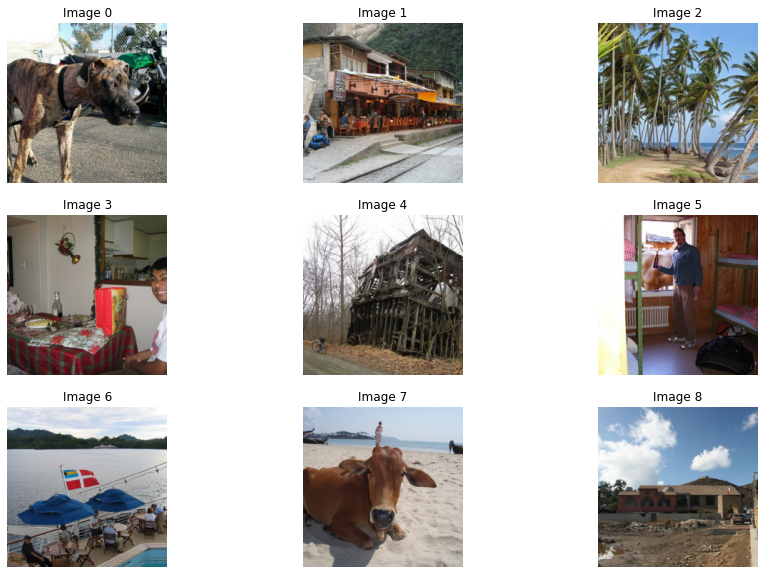

In [41]:
interp.plot_top_losses(k=9, figsize=(15,10))

In [42]:
learn.dls.after_batch

Pipeline: IntToFloatTensor -- {'div': 255.0, 'div_mask': 1} -> Flip -- {'size': 224, 'mode': 'bilinear', 'pad_mode': 'reflection', 'mode_mask': 'nearest', 'align_corners': True, 'p': 0.5} -> Brightness -- {'max_lighting': 0.2, 'p': 1.0, 'draw': None, 'batch': False} -> Normalize -- {'mean': tensor([[[[0.4850]],

         [[0.4560]],

         [[0.4060]]]], device='cuda:0'), 'std': tensor([[[[0.2290]],

         [[0.2240]],

         [[0.2250]]]], device='cuda:0'), 'axes': (0, 2, 3)}

In [43]:
learn.dls.vocab

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

**Reset test image**

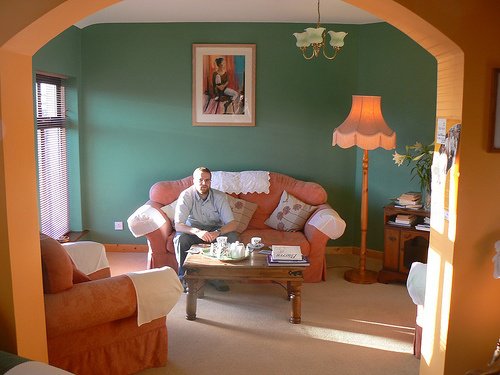

In [44]:
test_img = PIL.Image.open(test_file)
test_img

In [45]:
test_img.size

(500, 375)

In [46]:
min(test_img.size)

375

In [47]:
min_dim = test_img.size.index(min(test_img.size))
max_dim = 1 - min_dim

In [48]:
target_dim = 224

**Set input dims**

In [49]:
inp_dims = [0,0]
inp_dims[min_dim] = target_dim
inp_dims[max_dim] = int(test_img.size[max_dim] / (test_img.size[min_dim]/target_dim))
inp_dims

[298, 224]

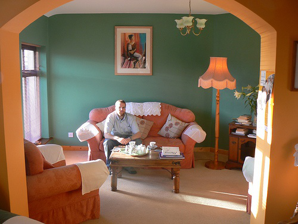

In [50]:
resized_img = test_img.resize(inp_dims)
resized_img

**Convert image to tensor**

In [51]:
img_tensor = tensor(resized_img).permute(2, 0, 1)
img_tensor.shape, img_tensor

(torch.Size([3, 224, 298]),
 tensor([[[125, 125, 125,  ...,  89,  89,  88],
          [127, 126, 128,  ...,  90,  89,  89],
          [127, 127, 128,  ...,  92,  91,  90],
          ...,
          [ 36,  41,  38,  ..., 109,  98,  80],
          [ 33,  42,  40,  ...,  73,  63,  57],
          [ 35,  41,  82,  ...,  53,  44,  51]],
 
         [[ 80,  80,  80,  ...,  30,  30,  29],
          [ 82,  81,  83,  ...,  30,  28,  30],
          [ 82,  82,  83,  ...,  32,  30,  29],
          ...,
          [ 31,  26,  31,  ...,  57,  44,  30],
          [ 30,  28,  32,  ...,  32,  23,  21],
          [ 34,  29,  73,  ...,  20,  19,  32]],
 
         [[ 41,  41,  41,  ...,   1,   1,   0],
          [ 43,  42,  43,  ...,   1,   0,   0],
          [ 43,  43,  43,  ...,   2,   1,   0],
          ...,
          [ 15,  15,  18,  ...,  17,   9,   5],
          [ 13,  15,  19,  ...,   5,   2,  11],
          [ 16,  15,  58,  ...,   0,   7,  33]]], dtype=torch.uint8))

**Scale tensor values**

In [52]:
scaled_tensor = img_tensor.float().div_(255)

**Prepare imagenet mean values**

In [53]:
mean_tensor = tensor(imagenet_stats[0]).view(1,1,-1).permute(2, 0, 1)
mean_tensor.shape, mean_tensor

(torch.Size([3, 1, 1]),
 tensor([[[0.4850]],
 
         [[0.4560]],
 
         [[0.4060]]]))

**Prepare imagenet std values**

In [54]:
std_tensor = tensor(imagenet_stats[1]).view(1,1,-1).permute(2, 0, 1)
std_tensor.shape, std_tensor

(torch.Size([3, 1, 1]),
 tensor([[[0.2290]],
 
         [[0.2240]],
 
         [[0.2250]]]))

**Normalize and batch image tensor**

In [55]:
normalized_tensor = (scaled_tensor - mean_tensor) / std_tensor
batched_tensor = normalized_tensor.unsqueeze(dim=0)
batched_tensor.shape, batched_tensor

(torch.Size([1, 3, 224, 298]),
 tensor([[[[ 0.0227,  0.0227,  0.0227,  ..., -0.5938, -0.5938, -0.6109],
           [ 0.0569,  0.0398,  0.0741,  ..., -0.5767, -0.5938, -0.5938],
           [ 0.0569,  0.0569,  0.0741,  ..., -0.5424, -0.5596, -0.5767],
           ...,
           [-1.5014, -1.4158, -1.4672,  ..., -0.2513, -0.4397, -0.7479],
           [-1.5528, -1.3987, -1.4329,  ..., -0.8678, -1.0390, -1.1418],
           [-1.5185, -1.4158, -0.7137,  ..., -1.2103, -1.3644, -1.2445]],
 
          [[-0.6352, -0.6352, -0.6352,  ..., -1.5105, -1.5105, -1.5280],
           [-0.6001, -0.6176, -0.5826,  ..., -1.5105, -1.5455, -1.5105],
           [-0.6001, -0.6001, -0.5826,  ..., -1.4755, -1.5105, -1.5280],
           ...,
           [-1.4930, -1.5805, -1.4930,  ..., -1.0378, -1.2654, -1.5105],
           [-1.5105, -1.5455, -1.4755,  ..., -1.4755, -1.6331, -1.6681],
           [-1.4405, -1.5280, -0.7577,  ..., -1.6856, -1.7031, -1.4755]],
 
          [[-1.0898, -1.0898, -1.0898,  ..., -1.7870, -

**Pass tensor to model**

In [56]:
with torch.no_grad():
    preds = learn.model(batched_tensor.cuda())
preds

TensorBase([[-5.5503, -7.5705, -5.4756, -7.6050, -4.6475, -6.8455, -6.0368, -3.6237,
          2.0273, -6.6316, -0.5561, -3.1160, -5.1924, -7.6037,  0.1002, -1.2070,
         -7.6334,  1.2739, -7.1457, -3.6513]], device='cuda:0')

In [57]:
rescaled_preds = torch.nn.functional.sigmoid(preds)
rescaled_preds

/home/innom-dt/mambaforge/envs/fastai-base/lib/python3.10/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


TensorBase([[3.8714e-03, 5.1515e-04, 4.1704e-03, 4.9769e-04, 9.4941e-03, 1.0631e-03,
         2.3835e-03, 2.5991e-02, 8.8364e-01, 1.3163e-03, 3.6444e-01, 4.2453e-02,
         5.5278e-03, 4.9838e-04, 5.2502e-01, 2.3022e-01, 4.8378e-04, 7.8140e-01,
         7.8761e-04, 2.5300e-02]], device='cuda:0')

In [58]:
[category for confidence, category in zip(rescaled_preds[0], learn.dls.vocab) if confidence > 0.2]

['chair', 'diningtable', 'person', 'pottedplant', 'sofa']

**Define ONNX file name**

In [59]:
onnx_file_name = f"{path.name}-{learn.arch.__name__}.onnx"
onnx_file_name

'pascal_2007-resnet18.onnx'

**Export trained model to ONNX**

In [60]:
torch.onnx.export(learn.model.cpu(),
                  batched_tensor,
                  onnx_file_name,
                  export_params=True,
                  opset_version=9,
                  do_constant_folding=True
                 )